### $\chi^2$ Test

Dataset from Kaggle: https://www.kaggle.com/datasets/raddar/smoking-related-lung-cancers

This is a subset of data available from the US National Lung Screening Trial (NLST). The data contains information about current and former smokers who were observed for 7 years and were tested for lung cancer each year. No non-smokers were involved in the trial.

Original Data contains:

- pid - anonymous identifier of a person
- age - age of a person at the start of the trial
- gender - Male/Female
- race - the race of a person
- smoker - Former/Current (Former is defined as quit smoking in last 15 years)
- days_to_cancer - number of days passed since the trial when the cancer was first observed
- stage_of_cancer - the stage of cancer when the cancer was first observed

In [1]:
# Full package
import pandas as pd
from pandas import crosstab # Contingency table by Pandas
import numpy as np
from scipy.stats import chi2_contingency # Chi^2 test by SciPy
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('lung_cancer.csv') # Original dataset with NaN
dataset

,pid,age,gender,race,smoker,days_to_cancer,stage_of_cancer
0,100001,70,Male,White,Current,NaN,NaN
1,100002,66,Male,White,Current,NaN,NaN
2,100003,64,Male,White,Current,NaN,NaN
3,100004,60,Male,White,Former,NaN,NaN
4,100005,64,Male,White,Former,NaN,NaN
...,...,...,...,...,...,...,...
53422,218890,73,Female,White,Current,NaN,NaN
53423,218891,66,Male,White,Current,NaN,NaN
53424,218892,56,Male,White,Former,NaN,NaN
53425,218893,69,Male,White,Former,NaN,NaN


In [3]:
fill_nan_days = lambda x: 0 if x == '' else x #  fills NaN values with zeros
fill_nan_stage = lambda x: 'Not observed' if x == '' else x #  fills NaN values with 'Not observed'
discard_pid_col = lambda col: col != 'pid' # Discard the pin column from the dataset

dataset = pd.read_csv( # Reworked dataset
    filepath_or_buffer = 'lung_cancer.csv',
    converters = { # Applying lambda functions
        'days_to_cancer': fill_nan_days,
        'stage_of_cancer': fill_nan_stage
    },
    usecols = discard_pid_col # discard the pid column
)

dataset['cancer_detected'] = np.where(dataset['days_to_cancer'] == 0, 'N', 'Y') # Add a new column: 'cancer_detected', boolean Yes or No
dataset

,age,gender,race,smoker,days_to_cancer,stage_of_cancer,cancer_detected
0,70,Male,White,Current,0,Not observed,N
1,66,Male,White,Current,0,Not observed,N
2,64,Male,White,Current,0,Not observed,N
3,60,Male,White,Former,0,Not observed,N
4,64,Male,White,Former,0,Not observed,N
...,...,...,...,...,...,...,...
53422,73,Female,White,Current,0,Not observed,N
53423,66,Male,White,Current,0,Not observed,N
53424,56,Male,White,Former,0,Not observed,N
53425,69,Male,White,Former,0,Not observed,N


In [4]:
(
    age,
    gender,
    race,
    smoker,
    days,
    stage,
    cancer_YN
 ) = (
    dataset['age'],
    dataset['gender'],
    dataset['race'],
    dataset['smoker'],
    dataset['days_to_cancer'],
    dataset['stage_of_cancer'],
    dataset['cancer_detected']
)

In [5]:
# Base statistic of overall age
(
    age.min(),
    age.max(),
    age.mode().values[0],
    age.median(),
    round(age.mean(), 2),
    round(age.std(), 2)
)

(np.int64(43),
 np.int64(79),
 np.int64(55),
 np.float64(60.0),
 np.float64(61.42),
 np.float64(5.02))

In [6]:
gender.value_counts(normalize = True) * 100.0 # How many females and males in %

gender
Male      58.990772
Female    41.009228
Name: proportion, dtype: float64

In [7]:
race.unique() # Unique values for race

<StringArray>
[                                    'White',
 'Native Hawaiian or Other Pacific Islander',
                        'More than one race',
                                     'Asian',
                                         nan,
                 'Black or African-American',
         'American Indian or Alaskan Native',
             'Participant refused to answer']
Length: 8, dtype: str

In [8]:
race.isnull().sum() # 261 NaN for race (but we don't care for our purpose)

np.int64(261)

In [9]:
dataset['race'].value_counts(dropna = False, normalize = True) * 100.0 # Counting values of race in %

race
White                                        90.828607
Black or African-American                     4.445318
Asian                                         2.049526
More than one race                            1.269021
NaN                                           0.488517
Native Hawaiian or Other Pacific Islander     0.359369
American Indian or Alaskan Native             0.355625
Participant refused to answer                 0.204017
Name: proportion, dtype: float64

In [10]:
smoker.value_counts() # How many formers and current smokers

smoker
Former     27680
Current    25747
Name: count, dtype: int64

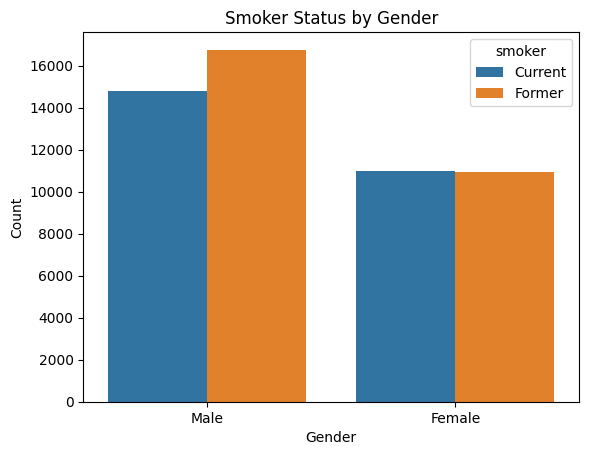

In [11]:
# Plotting data: Smoker status vs gender
sb.countplot(data = dataset, x = 'gender', hue = 'smoker')
plt.title('Smoker Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

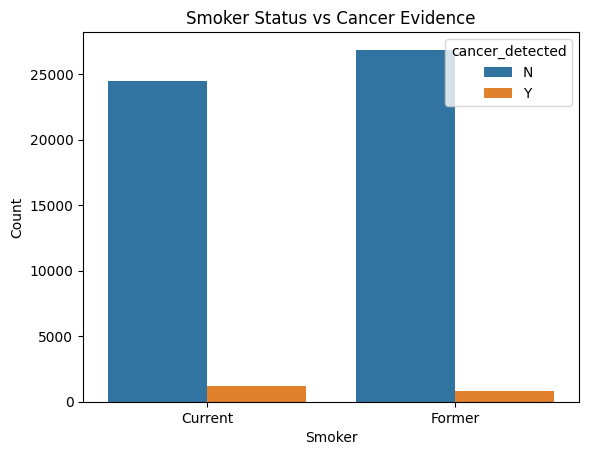

In [12]:
# Plotting data: smoker status vs cancer detected
sb.countplot(data = dataset, x = 'smoker', hue = 'cancer_detected')
plt.title('Smoker Status vs Cancer Evidence')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

Let's perform the $\chi^2$ independence test: smokers vs cancer evidence. We need to compute:

$$
    S = \sum_{j = 1}^{N} \, \frac{\left( O_{j} - E_{j} \right)^{2}}{E_{j}}
$$

$O_{j}$ is the observed value in the contingency table, while $E_{j}$ is the expected value if the null hypothesis is true. We can compute as follows:

$$
    E_{j} = \frac{(\text{row total})_{j} \times (\text{column total})_{j}}{\text{Total}}
$$

In [13]:
table = crosstab(smoker, cancer_YN, margins = True) # Contingency table
table

cancer_detected,N,Y,All
smoker,,,
Current,24519,1228,25747
Former,26875,805,27680
All,51394,2033,53427


In [14]:
# Chi^2 computed manually
total_current = table.iat[0, 2]
total_former = table.iat[1, 2]
total_N = table.iat[2, 0]
total_Y = table.iat[2, 1]
total = table.iat[2, 2]

E_00 = total_current * total_N / total; O_00 = table.iat[0, 0]
E_01 = total_current * total_Y / total; O_01 = table.iat[0, 1]
E_10 = total_former * total_N / total; O_10 = table.iat[1, 0]
E_11 = total_former * total_Y / total; O_11 = table.iat[1, 1]

E = np.array([E_00, E_01, E_10, E_11])
O = np.array([O_00, O_01, O_10, O_11])
S = np.sum((E - O) ** 2 / E)
E, S # print expected array and S

(array([24767.27718195,   979.72281805, 26626.72281805,  1053.27718195]),
 np.float64(126.2447896097068))

$S$ follows the $\chi^2$ distribution with $(\text{number of rows} - 1) \times (\text{number of columns} - 1) = 1 \, \text{(in our scenario)}$ number of degrees of freedom. The value obtained is very large. We shall reject the null hyphotesis of independence

In [15]:
# Same results using SciPy staff
chi2_contingency(table.iloc[: - 1 , : - 1]) # Remove both "All"

Chi2ContingencyResult(statistic=np.float64(125.73681836641398), pvalue=np.float64(3.5108943533095046e-29), dof=1, expected_freq=array([[24767.27718195,   979.72281805],
       [26626.72281805,  1053.27718195]]))